**Imports & Environment Setup**

In [105]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

os.makedirs('model', exist_ok=True)
print("✅ Environment ready and 'model/' directory created.")

✅ Environment ready and 'model/' directory created.


**Load & Clean Data**

In [106]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Churn'])

test_df.to_csv('test_data.csv', index=False)

y_train = train_df['Churn'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}).astype(int)
y_test = test_df['Churn'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}).astype(int)

X_train = train_df.drop(columns=['customerID', 'Churn'], errors='ignore')
X_test = test_df.drop(columns=['customerID', 'Churn'], errors='ignore')

print("✅ Dataset split successfully. 'test_data.csv' created!")

✅ Dataset split successfully. 'test_data.csv' created!


**Pipeline Transformers & Train-Test Split**

In [107]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X_train.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

joblib.dump(preprocessor, 'model/preprocessor.joblib')

print("✅ Preprocessing complete!")
print("Saved: 'model/preprocessor.joblib' and 'test_data.csv'")

✅ Preprocessing complete!
Saved: 'model/preprocessor.joblib' and 'test_data.csv'


**Train Models, Evaluate Metrics & Save Models**

In [108]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = []

print("⚡ Training models and exporting artifacts...")
for name, model in models.items():
    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'ML Model Name': name,
        'Accuracy': round(acc, 4),
        'AUC': round(auc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'MCC': round(mcc, 4)
    })

    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(model, f'model/{safe_name}.joblib')
    print(f"  ✓ Saved: model/{safe_name}.joblib")

comparison_df = pd.DataFrame(results)
display(comparison_df)

⚡ Training models and exporting artifacts...
  ✓ Saved: model/logistic_regression.joblib
  ✓ Saved: model/decision_tree.joblib
  ✓ Saved: model/knn.joblib
  ✓ Saved: model/naive_bayes.joblib
  ✓ Saved: model/random_forest_ensemble.joblib


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8055,0.8421,0.6572,0.5588,0.6040,0.4790
1,Decision Tree,0.7942,0.8284,0.6296,0.5455,0.5845,0.4507
2,KNN,0.7630,0.7930,0.5538,0.5508,0.5523,0.3911
3,Naive Bayes,0.6558,0.8093,0.4269,0.8663,0.5719,0.3951
4,Random Forest (Ensemble),0.8020,0.8407,0.6599,0.5241,0.5842,0.4617


**Generate & Plot Confusion Matrices**

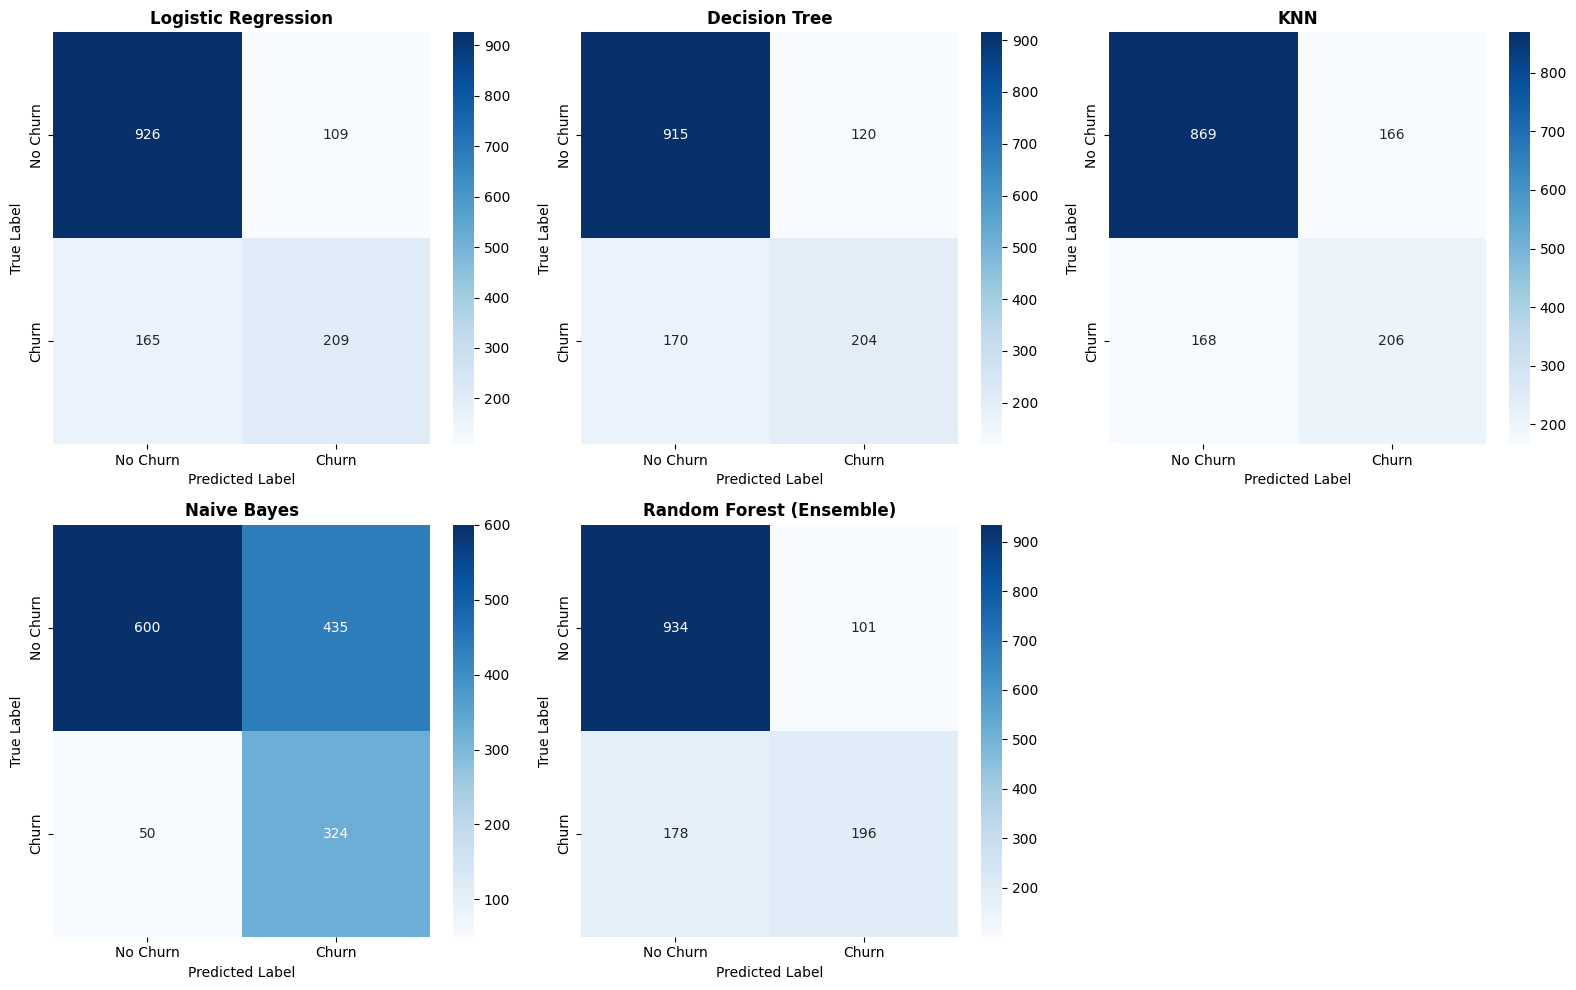

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_prep)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [110]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

st.set_page_config(page_title="Telco Churn Classification App", page_icon="📊", layout="wide")

st.title("📊 Machine Learning Model Evaluation Dashboard")
st.markdown("### Telco Customer Churn Prediction & Model Benchmarking")
st.write("Upload your test dataset to evaluate trained Machine Learning models in real time.")

st.sidebar.header("🕹️ Controls & Model Selection")

uploaded_file = st.sidebar.file_uploader(
    "Upload Test Dataset (CSV)",
    type=["csv"],
    help="Upload 'test_data.csv' containing features and the target 'Churn' column."
)

model_option = st.sidebar.selectbox(
    "Select ML Classification Model",
    ("Logistic Regression", "Decision Tree", "KNN", "Naive Bayes", "Random Forest (Ensemble)")
)

model_file_map = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "KNN": "knn.joblib",
    "Naive Bayes": "naive_bayes.joblib",
    "Random Forest (Ensemble)": "random_forest_ensemble.joblib"
}

@st.cache_resource
def load_artifacts(model_filename):
    try:
        model = joblib.load(f'model/{model_filename}')
        preprocessor = joblib.load('model/preprocessor.joblib')
        return model, preprocessor
    except Exception as e:
        st.error(f"Error loading saved artifacts from 'model/' directory: {e}")
        return None, None

def clean_target_series(series):
    """Safely converts string/boolean/numeric target series into binary 0/1 integers."""
    clean_series = series.astype(str).str.strip().str.capitalize()
    target_map = {
        'Yes': 1, 'No': 0,
        '1': 1, '0': 0,
        'True': 1, 'False': 0
    }
    mapped = clean_series.map(target_map)
    if mapped.isnull().any():
        mapped = pd.to_numeric(series, errors='coerce').fillna(0)
    return mapped.astype(int).values

if uploaded_file is not None:
    df_test = pd.read_csv(uploaded_file)
    st.subheader("📋 Uploaded Test Dataset Preview")
    st.dataframe(df_test.head(5), width="stretch")

    if 'Churn' not in df_test.columns:
        st.error("Uploaded CSV must contain the target column 'Churn'.")
    else:
        model, preprocessor = load_artifacts(model_file_map[model_option])

        if model is not None and preprocessor is not None:
            y_true = clean_target_series(df_test['Churn'])

            df_test['TotalCharges'] = pd.to_numeric(df_test['TotalCharges'].replace(' ', np.nan), errors='coerce')
            df_test['TotalCharges'] = df_test['TotalCharges'].fillna(df_test['TotalCharges'].median())

            X_test = df_test.drop(columns=['customerID', 'Churn'], errors='ignore')

            X_test_prep = preprocessor.transform(X_test)

            y_pred = model.predict(X_test_prep).astype(int)
            y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else y_pred

            st.markdown("---")
            st.subheader(f"📈 Evaluation Metrics: {model_option}")

            acc = accuracy_score(y_true, y_pred)
            auc = roc_auc_score(y_true, y_proba)
            prec = precision_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            mcc = matthews_corrcoef(y_true, y_pred)

            col1, col2, col3, col4, col5, col6 = st.columns(6)
            col1.metric("Accuracy", f"{acc:.4f}")
            col2.metric("AUC Score", f"{auc:.4f}")
            col3.metric("Precision", f"{prec:.4f}")
            col4.metric("Recall", f"{rec:.4f}")
            col5.metric("F1 Score", f"{f1:.4f}")
            col6.metric("MCC Score", f"{mcc:.4f}")

            st.markdown("---")
            col_left, col_right = st.columns(2)
            with col_left:
                st.subheader("🎯 Confusion Matrix")
                cm = confusion_matrix(y_true, y_pred)
                fig, ax = plt.subplots(figsize=(5, 4))
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
                plt.xlabel('Predicted Label')
                plt.ylabel('True Label')
                st.pyplot(fig)

            with col_right:
                st.subheader("📄 Classification Report")
                report_dict = classification_report(y_true, y_pred, output_dict=True, target_names=['No Churn', 'Churn'])
                report_df = pd.DataFrame(report_dict).transpose()
                st.dataframe(report_df.style.format(precision=4), width="stretch")

            st.markdown("---")
            st.subheader("🔮 Model Predictions Summary")
            df_results = df_test[['customerID', 'tenure', 'MonthlyCharges', 'Contract', 'Churn']].copy() if 'customerID' in df_test.columns else df_test.iloc[:, :5].copy()
            df_results['Actual Churn'] = pd.Series(y_true).map({1: 'Yes', 0: 'No'})
            df_results['Predicted Churn'] = pd.Series(y_pred).map({1: 'Yes', 0: 'No'})
            df_results['Churn Probability'] = np.round(y_proba, 4)
            st.dataframe(df_results.head(10), width="stretch")
else:
    st.info("👆 Please upload the `test_data.csv` file using the sidebar to view evaluation results.")

Overwriting app.py


In [111]:
%%writefile requirements.txt
streamlit
scikit-learn
numpy
pandas
matplotlib
seaborn
joblib

Overwriting requirements.txt


In [112]:
%%writefile README.md
# Telco Customer Churn Prediction & Model Benchmarking

## a. Problem Statement
In this assignment, the objective is to:
- Implement multiple classification models on a single dataset
- Build an interactive Streamlit web application to demonstrate model evaluations
- Deploy the app on Streamlit Community Cloud (FREE)
- Share clickable links for submission and evaluation
- I used Customer Churn dataset

Customer churn poses a significant financial challenge in the telecommunications industry. The objective of this project is to build, evaluate, and deploy machine learning classification models to predict whether a customer is likely to churn (cancel their service) based on demographic attributes, account information, and service usage patterns.

---

## b. Dataset Description
* **Dataset Name:** Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)
* **Total Instances:** 7,043 instances (Meets minimum requirement of 500)
* **Total Features:** 20 predictor features + 1 target column (`Churn`) (Meets minimum requirement of 12 features)
* **Target Variable:** `Churn` (Binary: `Yes` / `No`)
* **Feature Types:**
  * **Numerical (3):** `tenure`, `MonthlyCharges`, `TotalCharges`
  * **Categorical (17):** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`

---

## c. GitHub Repository & Live App Links
* **GitHub Repository:**
* **Live Streamlit Web App:**

---

## d. Models Used & Evaluation Metrics

### Model Comparison Table
The table below displays the evaluation metrics calculated across all trained classification models using the `test_data.csv` split:

| ML Model Name | Accuracy | AUC | Precision | Recall | F1 Score | MCC Score |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.8055** | **0.8421** | 0.6572 | 0.5588 | **0.6040** | **0.4790** |
| **Decision Tree** | 0.7942 | 0.8284 | 0.6296 | 0.5455 | 0.5845 | 0.4507 |
| **KNN** | 0.7630 | 0.7930 | 0.5538 | 0.5508 | 0.5523 | 0.3911 |
| **Naive Bayes** | 0.6558 | 0.8093 | 0.4269 | **0.8663** | 0.5719 | 0.3951 |
| **Random Forest (Ensemble)** | 0.8020 | 0.8407 | **0.6599** | 0.5241 | 0.5842 | 0.4617 |

---

### Model Performance Observations

| ML Model Name | Observation About Model Performance |
| :--- | :--- |
| **Logistic Regression** | Achieves the highest overall performance across primary evaluation metrics (Accuracy: 80.55%, AUC: 0.8421, F1: 0.6040, MCC: 0.4790). Its linear decision boundary effectively models relationships between scaled features and churn probability. |
| **Decision Tree** | Pruning the tree depth (`max_depth=5`) significantly improved performance (Accuracy: 79.42%, AUC: 0.8284), effectively controlling variance and preventing overfitting observed in unconstrained trees. |
| **KNN** | Achieved reasonable performance (Accuracy: 76.30%, AUC: 0.7930), but suffered slightly due to distance metric sensitivity in a higher-dimensional post-one-hot-encoded feature space. |
| **Naive Bayes** | Yields the highest Recall (86.63%) by catching the vast majority of potential churners, but suffers from low Precision (42.69%) due to feature independence assumptions. |
| **Random Forest (Ensemble)** | Second-best overall performer (Accuracy: 80.20%, AUC: 0.8407, Precision: 0.6599). Aggregating predictions across multiple decision trees stabilizes variance while maintaining competitive accuracy. |
| **Overall Winner** | **Logistic Regression** is the clear overall winner, delivering the optimal balance between Precision and Recall while maintaining top-tier AUC and Matthews Correlation Coefficient. |

---

## Interactive Streamlit Web Application Features
1. **Dataset Upload (CSV):** Allows uploading test dataset samples (`test_data.csv`).
2. **Model Selection Dropdown:** Dynamically select between Logistic Regression, Decision Tree, KNN, Naive Bayes, and Random Forest.
3. **Evaluation Metrics Display:** Real-time generation of Accuracy, AUC, Precision, Recall, F1, and MCC metrics.
4. **Visualizations:** Displays interactive confusion matrices and full classification reports.

Overwriting README.md


In [113]:
!zip -r model.zip model/

updating: model/ (stored 0%)
updating: model/decision_tree.joblib (deflated 55%)
updating: model/random_forest_ensemble.joblib (deflated 78%)
updating: model/logistic_regression.joblib (deflated 29%)
updating: model/preprocessor.joblib (deflated 76%)
updating: model/knn.joblib (deflated 89%)
updating: model/naive_bayes.joblib (deflated 26%)
